## Data-driven modelling of cooperative decision-making under resource inequality in an urban collective-risk dilemma
#### Conditional contribution probability hypotheses:
 - $H_0$: Probability of the next contribution based on the previous one.
 - $H_1$: Probability of the next contribution based on the previous average contribution of others.
 - $H_2$: Probability of the next contribution based on the Cumulative contribution of all players.
 - $H_3$: Probability of the next contribution based on the remaining relative coins.

In [1]:
#Register some PC Stats
%load_ext watermark
%watermark

Last updated: 2026-04-27T18:17:44.465203+02:00

Python implementation: CPython
Python version       : 3.14.3
IPython version      : 9.10.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : AMD64 Family 25 Model 124 Stepping 0, AuthenticAMD
CPU cores   : 12
Architecture: 64bit



In [2]:
#Importing all libraries needed
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
# Set Pandas to display all columns
pd.set_option('display.max_columns', None)
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
%matplotlib inline

In [ ]:
# Ensure the folder exists
output_folder = "Figures/ConditionalProbabilities/"
os.makedirs(output_folder, exist_ok=True)

In [5]:
#Reading the users dataset
df_users = pd.read_csv("Datasets/df_users_six_players.csv")

In [6]:
# Define round columns
round_columns = [f'R{i}' for i in range(1, 11)]
# Define possible contribution choices
contribution_choices = [0.0, 2.0, 4.0]

$H_0$: Markov conditional probabilities by endowment

30


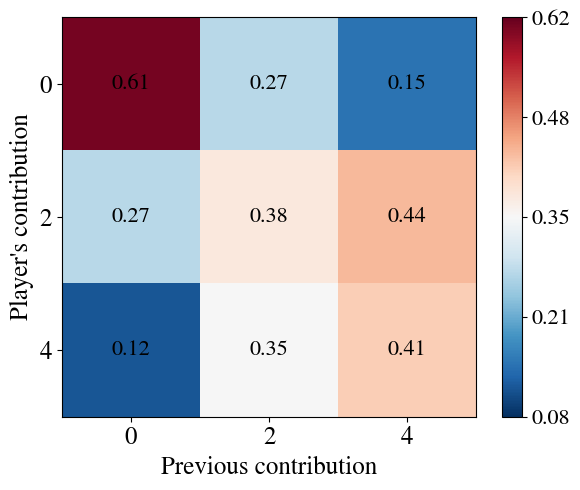

60


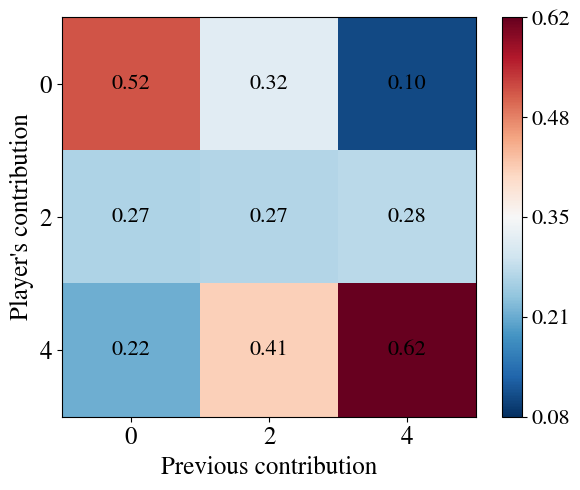

48


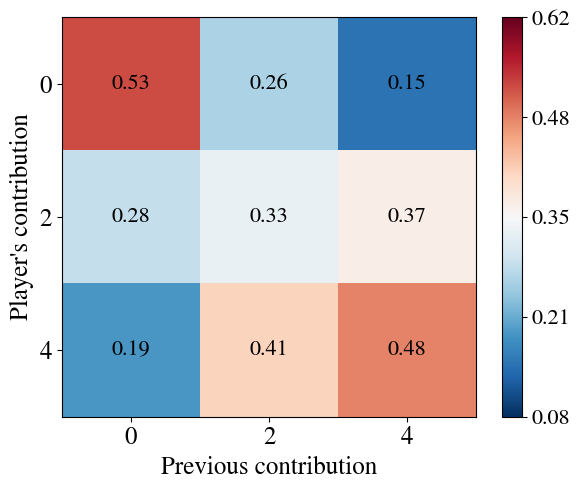

24


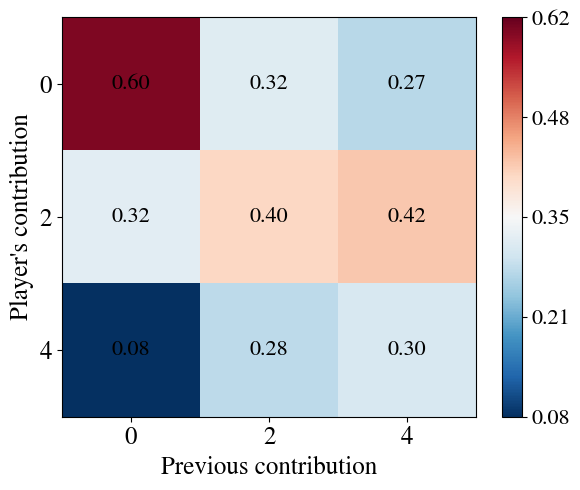

40


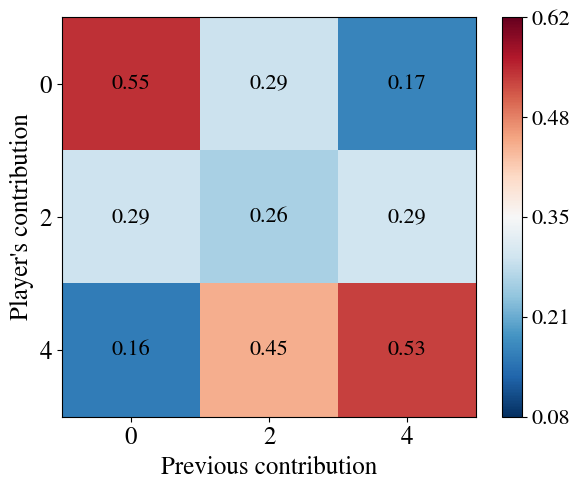

In [8]:
# Compute transition matrices per endowment only
transition_matrices_per_endowment = {}
probabilities_df = {}

for endowment in df_users["endowment_initial"].unique():
    # Filter dataset
    subset = df_users[df_users["endowment_initial"] == endowment].copy()

    # Initialize transition matrix
    transition_matrix = pd.DataFrame(0, index=contribution_choices, columns=contribution_choices, dtype=float)

    # Populate matrix with transition counts
    for _, player in subset.iterrows():
        contributions = player[round_columns].values
        for i in range(len(contributions) - 1):
            transition_matrix.loc[contributions[i+1], contributions[i]] += 1

    # Normalize to get probabilities
    transition_matrix = transition_matrix.div(transition_matrix.sum(axis=0), axis=1).fillna(0)

    transition_matrices_per_endowment[endowment] = transition_matrix
    probabilities_df[endowment] = transition_matrix.T

# Define colormap
cmap = plt.get_cmap("RdBu_r")

# Compute global vmin and vmax across all endowment matrices
all_values = pd.concat([df.stack() for df in transition_matrices_per_endowment.values()])
vmin = all_values.min()
vmax = all_values.max()

# Plot heatmaps for transition matrices using Matplotlib (one per endowment)
for endowment, matrix in transition_matrices_per_endowment.items():
    fig, ax = plt.subplots(figsize=(6, 5))

    # Plot the heatmap with vmin and vmax fixed
    cax = ax.imshow(matrix, cmap=cmap, aspect="auto", origin="upper",
                    interpolation="nearest", vmin=vmin, vmax=vmax)

    # Add colorbar with custom ticks
    cbar = fig.colorbar(cax, ax=ax)
    ticks = np.linspace(vmin, vmax, 5)  # 7 ticks: min + 5 in between + max
    cbar.set_ticks(ticks)
    cbar.ax.tick_params(labelsize=16)  # You can adjust 14 to your preference
    cbar.ax.set_yticklabels([f"{tick:.2f}" for tick in ticks])

    # Set tick labels
    ax.set_xticks(np.arange(len(contribution_choices)))
    ax.set_yticks(np.arange(len(contribution_choices)))
    ax.set_xticklabels([int(label) for label in contribution_choices])
    ax.set_yticklabels([int(label) for label in contribution_choices])

    # Annotate the values (ensuring they appear correctly)
    for i in range(len(contribution_choices)):
        for j in range(len(contribution_choices)):
            value = matrix.iloc[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=16)

    # Labels and title
    ax.set_ylabel("Player's contribution", fontsize=18)
    ax.set_xlabel("Previous contribution", fontsize=18)
    #ax.set_title(f"Endowment = {endowment}", fontsize=14)
    ax.tick_params(labelcolor='black', labelsize=18)

    # Save plot
    plt.tight_layout()
    plt.savefig(f"{output_folder}/Previous Contribution Endowment_{endowment}.pdf",bbox_inches='tight', pad_inches=0.1)
    print(endowment)
    # Show plot
    plt.show()

In [9]:
# Convert to DataFrame
probabilities_df_with_index = {endowment: matrix.reset_index() for endowment, matrix in probabilities_df.items()}
probability_previous = pd.concat(probabilities_df_with_index, names=["endowment_initial"]).reset_index(level=1, drop=True)
probability_previous=probability_previous.rename(columns={'index': 'Previous_Contribution'})
#Saving Previous Probabilities in a csv
probability_previous.to_csv('Datasets/H0_Previous_contribution.csv', index=True)

$H_1$: Altruistic conditional probabilities by endowment

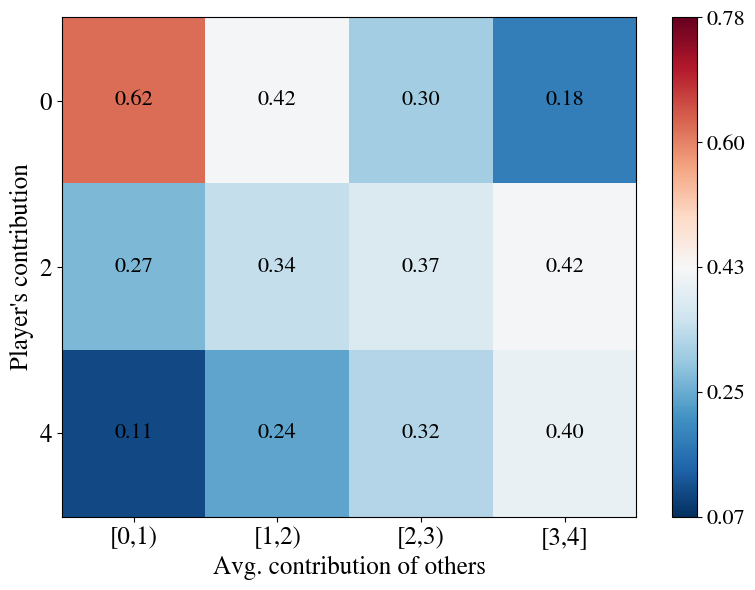

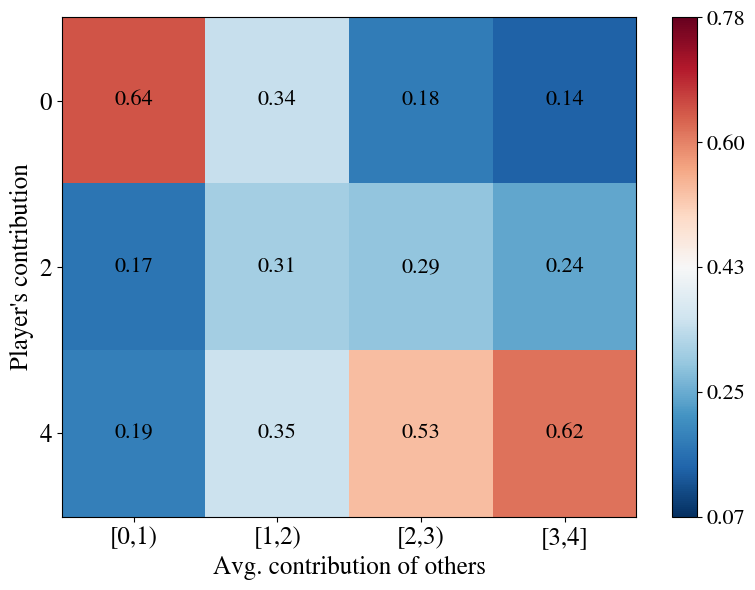

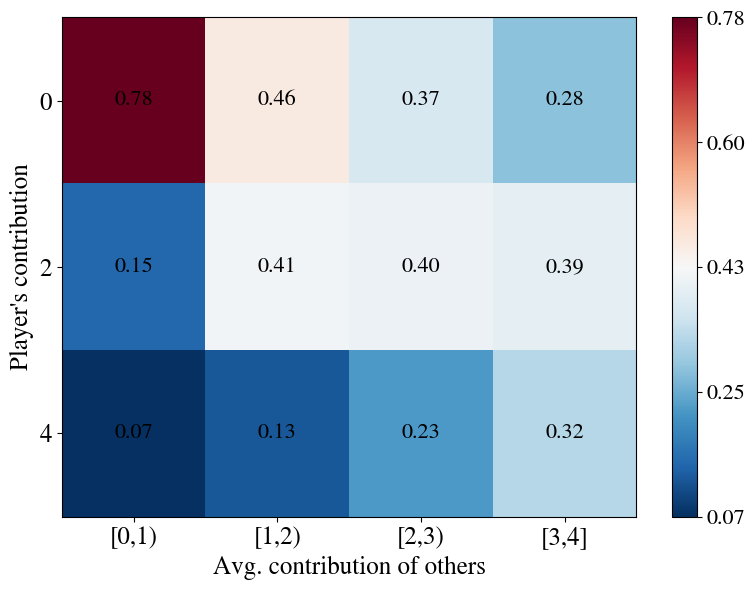

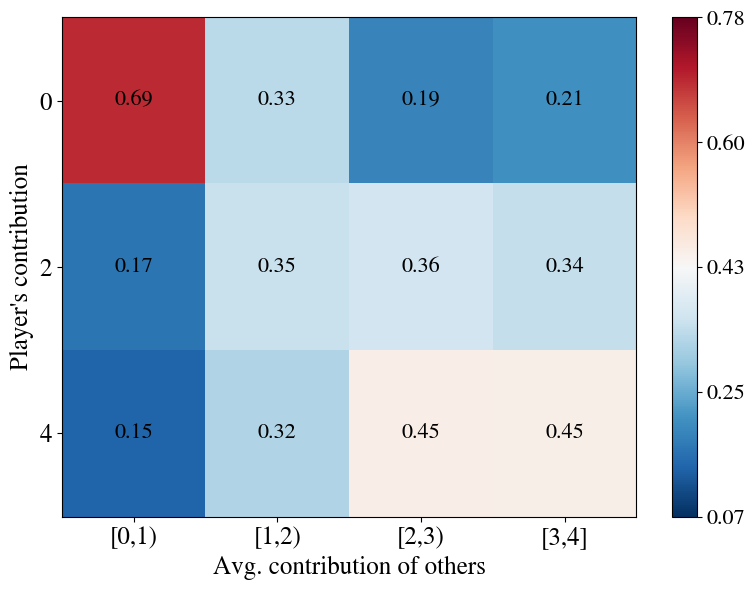

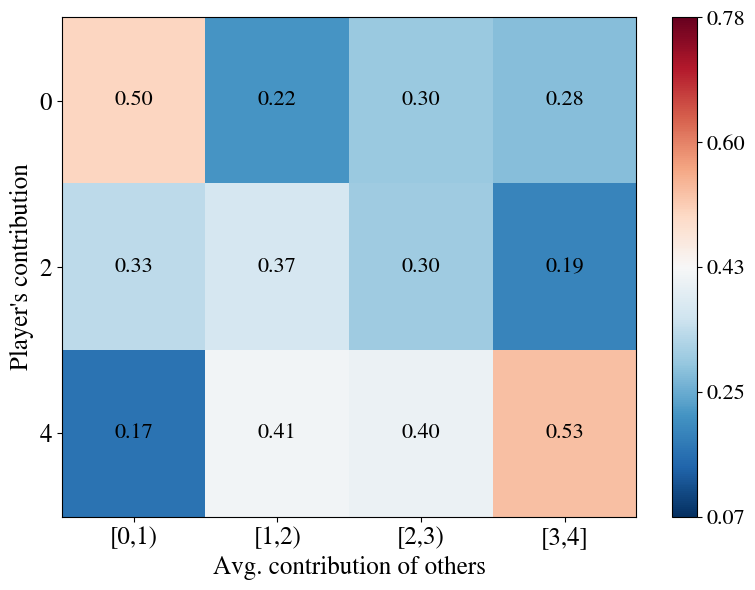

In [10]:
# Placeholder for contribution probability results
contribution_probability_results = []

# Define bins for average contribution of others
bins = [0, 1, 2, 3, float("inf")]  # Fixed ranges
bin_labels = ["[0,1)", "[1,2)", "[2,3)", "[3,4]"]

df=df_users.copy()

# Iterate over games (partida_id)
for partida_id, game_data in df.groupby("partida_id"):
    for endowment, endowment_data in game_data.groupby("endowment_initial"):
        for _, player in endowment_data.iterrows():
            contributions = player[round_columns].values

            for round_index in range(len(round_columns) - 1):
                prev_round = round_columns[round_index]
                curr_round = round_columns[round_index + 1]

                # Get contributions of others in the previous round
                other_players = game_data[game_data["id"] != player["id"]]
                other_contributions = other_players[prev_round].values
                avg_others = other_contributions.mean()

                contribution_probability_results.append({
                    "partida_id": partida_id,
                    "player_id": player["id"],
                    "control_wealth": game_data["control_wealth"].iloc[0],
                    "endowment_initial": endowment,
                    "previous_avg_others": avg_others,
                    "current_contribution": player[curr_round]
                })

# Convert to DataFrame
df_contrib_prob = pd.DataFrame(contribution_probability_results)

# Bin the `previous_avg_others` values
df_contrib_prob["previous_avg_others_binned"] = pd.cut(df_contrib_prob["previous_avg_others"], bins=bins, labels=bin_labels, include_lowest=True, right=False)

# Compute probability of contributing 0, 2, or 4 given average previous contributions (binned)
probability_others = df_contrib_prob.groupby(
    ["endowment_initial", "previous_avg_others_binned"]
)["current_contribution"].value_counts(normalize=True).unstack()

# Compute global vmin and vmax from all matrices in probability_others
all_values = []
for endowment in df_contrib_prob["endowment_initial"].unique():
    if endowment in probability_others.index:
        mat = probability_others.loc[endowment].fillna(0).values
        all_values.append(mat)

# Combine all values into one array to find min and max
all_values_combined = np.concatenate(all_values).flatten()
vmin = all_values_combined.min()
vmax = all_values_combined.max()

# Create heatmaps using Matplotlib
for endowment in df_contrib_prob["endowment_initial"].unique():
    data = probability_others.loc[endowment].fillna(0).T  # Ensure missing values are set to 0

    # Create a figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Define color scale
    cmap = plt.get_cmap("RdBu_r")

    # Plot the heatmap with vmin and vmax fixed
    cax = ax.imshow(data, cmap=cmap, aspect="auto", origin="upper",
                    interpolation="nearest", vmin=vmin, vmax=vmax)

    # Add colorbar with custom ticks
    cbar = fig.colorbar(cax, ax=ax)
    ticks = np.linspace(vmin, vmax, 5)  # 7 ticks: min + 5 in between + max
    cbar.set_ticks(ticks)
    cbar.ax.tick_params(labelsize=16)  # You can adjust 14 to your preference
    cbar.ax.set_yticklabels([f"{tick:.2f}" for tick in ticks])

    # Set tick labels
    ax.set_xticks(np.arange(len(bin_labels)))
    ax.set_xticklabels(bin_labels)
    ax.set_yticks(np.arange(len(data.index)))
    ax.set_yticklabels([int(label) for label in data.index])

    # Annotate the values (ensuring they appear correctly)
    for i in range(len(data.index)):
        for j in range(len(bin_labels)):
            value = data.iloc[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=16)

    # Labels and title
    ax.set_xlabel("Avg. contribution of others", fontsize=18)
    ax.set_ylabel("Player's contribution", fontsize=18)
    ax.tick_params(labelcolor='black', labelsize=18)

    # Save plot
    plt.tight_layout()
    plt.savefig(f"{output_folder}/Others Contribution Endowment_{endowment}.pdf",
                bbox_inches='tight', pad_inches=0.1)
    # Show plot
    plt.show()

In [11]:
#Saving Others Probabilities in a csv
probability_others.to_csv('Datasets/H1_Others_contribution.csv', index=True)

$H_2$: Target-based conditional probabilities by endowment

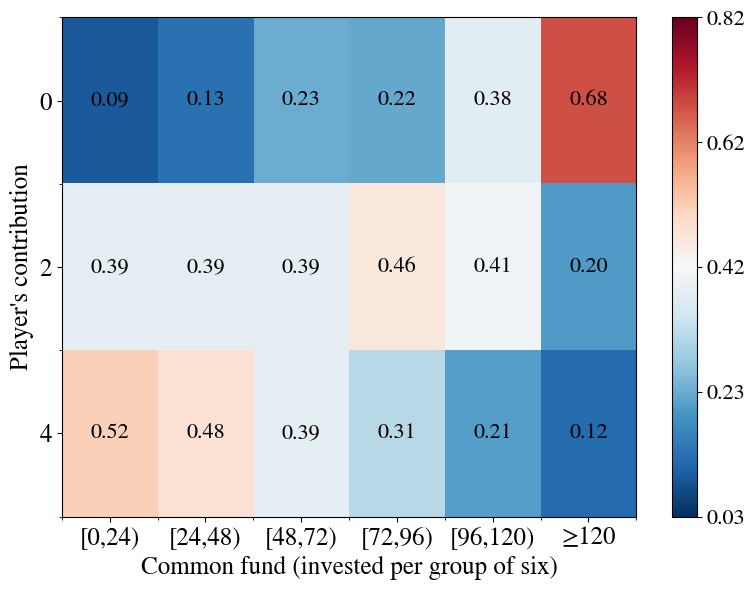

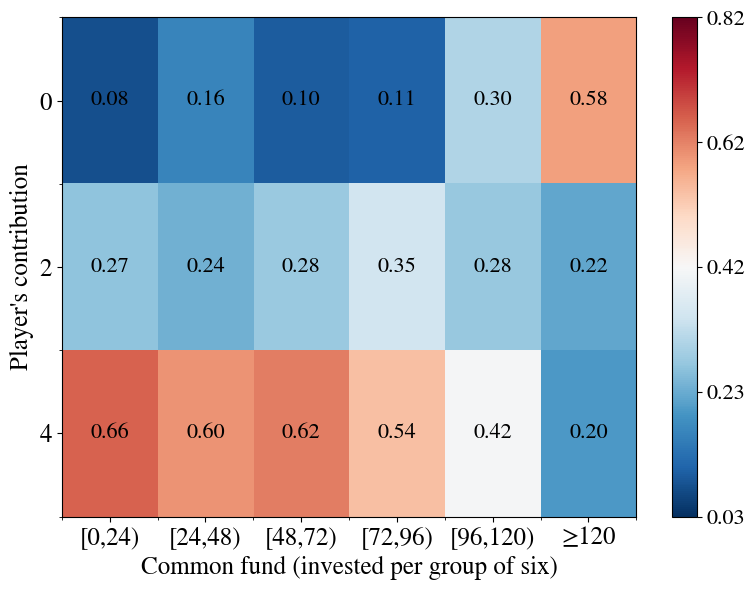

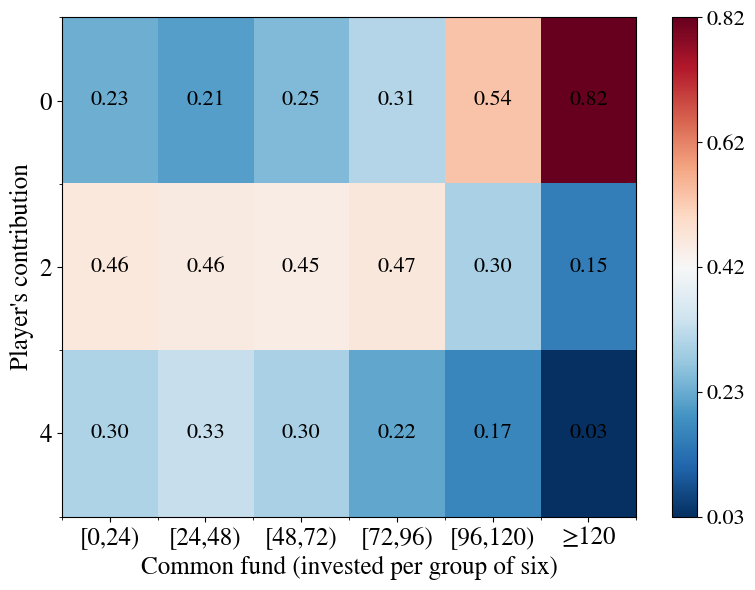

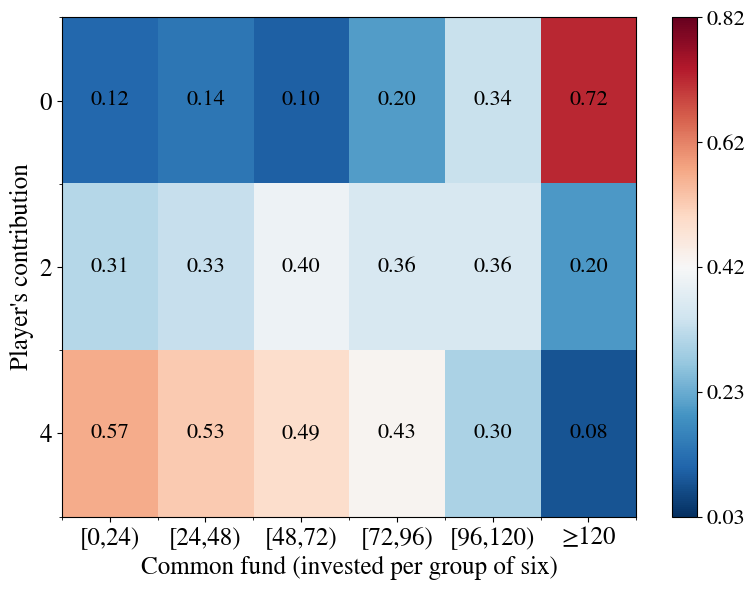

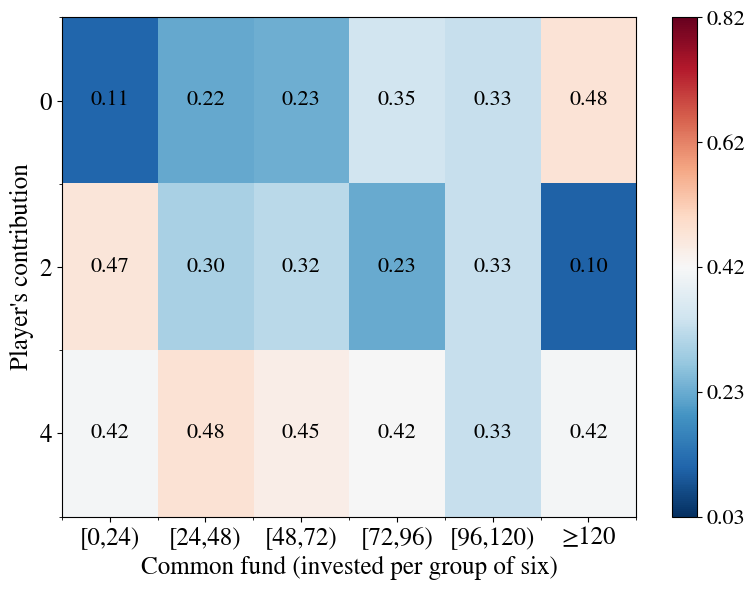

In [12]:
# Placeholder for contribution probability results
contribution_probability_results = []

# Define bins for cumulative contribution of all players
bins = [0, 24, 48, 72, 96, 120, float("inf")]  # Fixed ranges
bin_labels = ["[0,24)", "[24,48)", "[48,72)", "[72,96)", "[96,120)", "≥120"]

df=df_users.copy()

# Iterate over games (partida_id)
for partida_id, game_data in df.groupby("partida_id"):
    for endowment, endowment_data in game_data.groupby("endowment_initial"):
        for _, player in endowment_data.iterrows():
            contributions = player[round_columns].values

            cumulative_contribution = 0  # Track cumulative contribution

            for round_index in range(len(round_columns) - 1):
                prev_round = round_columns[round_index]
                curr_round = round_columns[round_index + 1]

                # Update cumulative contribution of all players up to the previous round
                cumulative_contribution += game_data[prev_round].sum()

                contribution_probability_results.append({
                    "partida_id": partida_id,
                    "player_id": player["id"],
                    "control_wealth": game_data["control_wealth"].iloc[0],
                    "endowment_initial": endowment,
                    "previous_cumulative_contribution": cumulative_contribution,
                    "current_contribution": player[curr_round]
                })

# Convert to DataFrame
df_contrib_prob = pd.DataFrame(contribution_probability_results)

# Bin the `previous_cumulative_contribution` values
df_contrib_prob["previous_cumulative_contribution_binned"] = pd.cut(
    df_contrib_prob["previous_cumulative_contribution"], bins=bins, labels=bin_labels, include_lowest=True, right=False)

# Compute probability of contributing 0, 2, or 4 given cumulative previous contributions (binned)
probability_matrices = df_contrib_prob.groupby(
    ["endowment_initial", "previous_cumulative_contribution_binned"]
)["current_contribution"].value_counts(normalize=True).unstack()

# Compute global vmin and vmax from all matrices in probability_others
all_values = []
for endowment in df_contrib_prob["endowment_initial"].unique():
    if endowment in probability_matrices.index:
        mat = probability_matrices.loc[endowment].fillna(0).values
        all_values.append(mat)

# Combine all values into one array to find min and max
all_values_combined = np.concatenate(all_values).flatten()
vmin = all_values_combined.min()
vmax = all_values_combined.max()

# Create heatmaps using Matplotlib
for endowment in df_contrib_prob["endowment_initial"].unique():
    if endowment not in probability_matrices.index:
        continue  # Skip if no data for this endowment

    data = probability_matrices.loc[endowment].fillna(0).T  # Ensure missing values are set to 0

    # Create a figure
    fig, ax = plt.subplots(figsize=(8, 6))

    # Define color scale
    cmap = plt.get_cmap("RdBu_r")

    # Plot the heatmap with vmin and vmax fixed
    cax = ax.imshow(data, cmap=cmap, aspect="auto", origin="upper",
                    interpolation="nearest", vmin=vmin, vmax=vmax)

    # Add colorbar with custom ticks
    cbar = fig.colorbar(cax, ax=ax)
    ticks = np.linspace(vmin, vmax, 5)  # 7 ticks: min + 5 in between + max
    cbar.set_ticks(ticks)
    cbar.ax.tick_params(labelsize=16)  # You can adjust 14 to your preference
    cbar.ax.set_yticklabels([f"{tick:.2f}" for tick in ticks])

    # Ensure correct label alignment
    ax.set_xticks(np.arange(len(data.columns)))
    ax.set_xticklabels(data.columns)
    ax.set_yticks(np.arange(len(data.index)))
    ax.set_yticklabels([int(label) for label in data.index])

    # Remove white grid lines
    ax.set_xticks(np.arange(-0.5, len(data.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(data.index), 1), minor=True)
    ax.grid(False, which="both")  # Remove grid lines

    # Annotate the values (ensuring correct alignment)
    for i in range(len(data.index)):  # Iterate over rows
        for j in range(len(data.columns)):  # Iterate over columns
            value = data.iloc[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=16)

    # Labels and title
    ax.set_xlabel("Common fund (invested per group of six)", fontsize=18)
    ax.set_ylabel("Player's contribution", fontsize=18)
    ax.tick_params(labelcolor='black', labelsize=18)

    # Save plot
    plt.tight_layout()
    plt.savefig(f"{output_folder}/Cumulative Contribution Endowment_{endowment}.pdf",
                bbox_inches='tight', pad_inches=0.1)

    # Show plot
    plt.show()

In [13]:
#Saving cumulative Probabilities in a csv
probability_matrices.to_csv('Datasets/H2_Cumulative_contribution.csv', index=True)

$H_3$: Selfish conditional probabilities by endowment

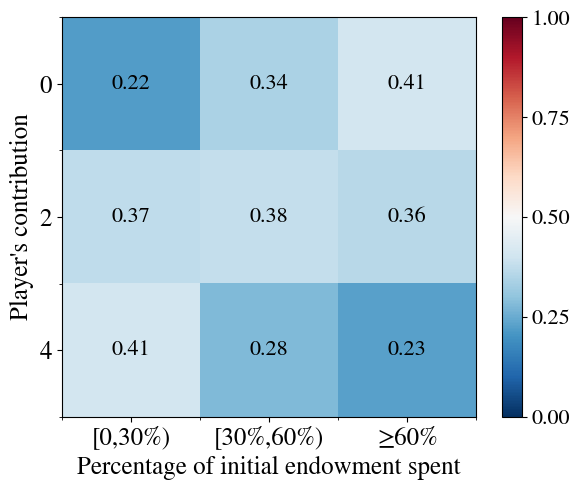

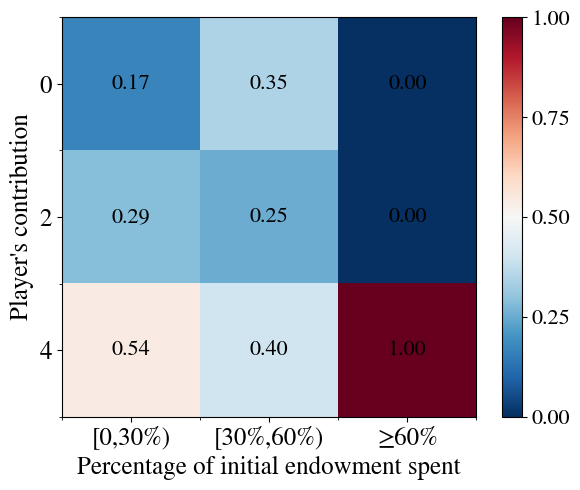

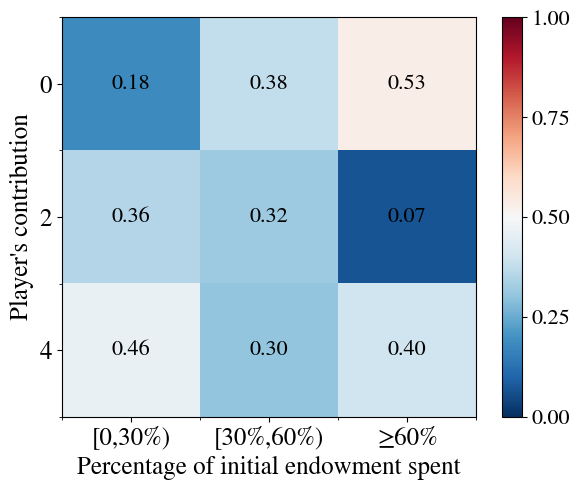

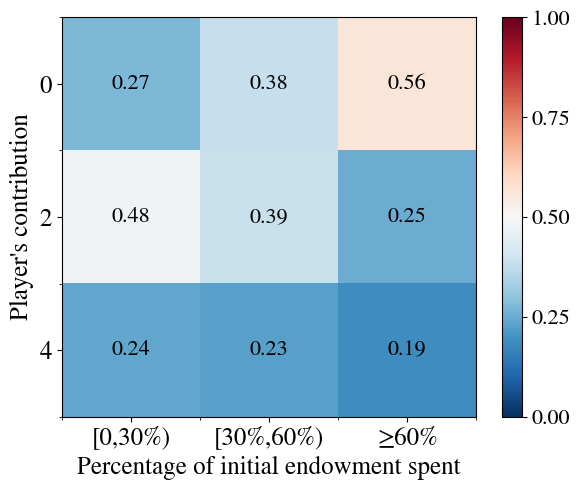

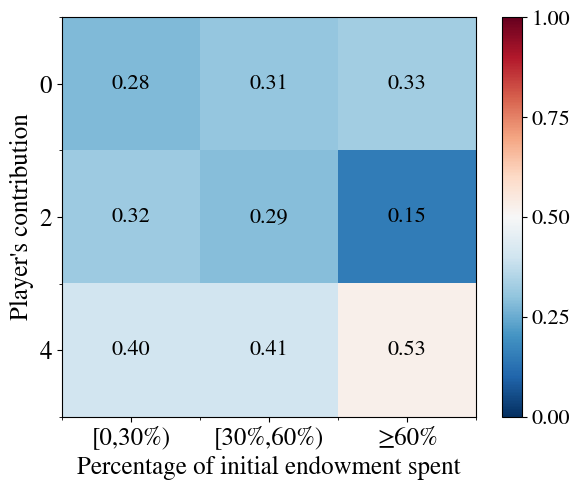

In [14]:
bins = [0, 3/10, 6/10, float("inf")]  # Fixed ranges
bin_labels = ["[0,30%)", "[30%,60%)", "≥60%"]

# Ensure all possible bins and contributions are present
expected_contributions = [0.0, 2.0, 4.0]
expected_bins = bin_labels

# Placeholder for results
spending_probability_results = []

df=df_users.copy()

# Iterate over users to compute probabilities based on spent relative coins
for _, player in df.iterrows():
    initial_endowment = player["endowment_initial"]
    cumulative_contribution = 0  # Track cumulative contribution over rounds

    for round_index in range(len(round_columns) - 1):
        prev_round = round_columns[round_index]
        curr_round = round_columns[round_index + 1]

        # Update cumulative contribution (sum of all contributions up to this round)
        cumulative_contribution += player[prev_round]

        # Compute spent relative coins at this round
        spent_ratio = cumulative_contribution / initial_endowment

        spending_probability_results.append({
            "player_id": player["id"],
            "control_wealth": player["control_wealth"],
            "endowment_initial": initial_endowment,
            "spent_ratio": spent_ratio,
            "current_contribution": player[curr_round]
        })

# Convert to DataFrame
df_spending_prob = pd.DataFrame(spending_probability_results)

# Ensure `spent_ratio` exists before binning
if "spent_ratio" in df_spending_prob.columns:
    df_spending_prob["spent_ratio_binned"] = pd.cut(
        df_spending_prob["spent_ratio"], bins=bins, labels=bin_labels, include_lowest=True, right=False
    )

# Compute probability of contributing 0, 2, or 4 given the spent ratio (binned)
spending_probability_matrices = df_spending_prob.groupby(
    ["endowment_initial", "spent_ratio_binned"]
)["current_contribution"].value_counts(normalize=True).unstack()

# Compute global vmin and vmax from all matrices in probability_others
all_values = []
for endowment in df_spending_prob["endowment_initial"].unique():
    if endowment in spending_probability_matrices.index:
        mat = spending_probability_matrices.loc[endowment].fillna(0).values
        all_values.append(mat)

# Combine all values into one array to find min and max
all_values_combined = np.concatenate(all_values).flatten()
vmin = all_values_combined.min()
vmax = all_values_combined.max()

# Create heatmaps using Matplotlib
for endowment in df_spending_prob["endowment_initial"].unique():
    if endowment not in spending_probability_matrices.index:
        continue  # Skip if no data for this endowment

    # Reindex to ensure full 3x3 matrix
    data = spending_probability_matrices.loc[endowment].reindex(index=expected_bins, columns=expected_contributions, fill_value=0).fillna(0).T

    # Create a figure
    fig, ax = plt.subplots(figsize=(6, 5))

    # Define color scale
    cmap = plt.get_cmap("RdBu_r")

    # Plot the heatmap with vmin and vmax fixed
    cax = ax.imshow(data, cmap=cmap, aspect="auto", origin="upper",
                    interpolation="nearest", vmin=vmin, vmax=vmax)

    # Add colorbar with custom ticks
    cbar = fig.colorbar(cax, ax=ax)
    ticks = np.linspace(vmin, vmax, 5)  # 7 ticks: min + 5 in between + max
    cbar.set_ticks(ticks)
    cbar.ax.tick_params(labelsize=16)  # You can adjust 14 to your preference
    cbar.ax.set_yticklabels([f"{tick:.2f}" for tick in ticks])

    # Ensure correct label alignment
    ax.set_xticks(np.arange(len(data.columns)))
    ax.set_xticklabels(data.columns)
    ax.set_yticks(np.arange(len(data.index)))
    ax.set_yticklabels([int(label) for label in data.index])

    # Remove white grid lines
    ax.set_xticks(np.arange(-0.5, len(data.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(data.index), 1), minor=True)
    ax.grid(False, which="both")  # Remove grid lines

    # Annotate the values (ensuring correct alignment)
    for i in range(len(data.index)):  # Iterate over rows
        for j in range(len(data.columns)):  # Iterate over columns
            value = data.iloc[i, j]
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=16)

    # Labels and title
    ax.set_xlabel("Percentage of initial endowment spent", fontsize=18)
    ax.set_ylabel("Player's contribution", fontsize=18)
    ax.tick_params(labelcolor='black', labelsize=18)

    # Save plot
    plt.tight_layout()
    plt.savefig(f"{output_folder}/Spent coins Endowment_{endowment}.pdf",
                bbox_inches='tight', pad_inches=0.1)
    # Show plot
    plt.show()

In [ ]:
# Define expected index and columns
expected_bins = pd.Categorical(bin_labels, categories=bin_labels, ordered=True)
expected_contributions = [0.0, 2.0, 4.0]

# Create a list to collect complete reindexed DataFrames
complete_entries = []

for endowment in spending_probability_matrices.index.levels[0]:
    matrix = spending_probability_matrices.loc[endowment]
    
    # Reindex with all bins and contribution columns
    matrix = matrix.reindex(index=expected_bins, columns=expected_contributions, fill_value=0).fillna(0)

    # Add back the endowment as a level to match the original structure
    matrix["endowment_initial"] = endowment
    matrix = matrix.reset_index().set_index(["endowment_initial", "spent_ratio_binned"])
    
    complete_entries.append(matrix)

# Concatenate all into a complete, uniform matrix
spending_probability_matrices_complete = pd.concat(complete_entries).sort_index()

# Save to CSV
spending_probability_matrices_complete.to_csv("Datasets/H3_Spending_coins.csv", index=True)